Nominal Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_nominal = pd.read_csv("Datasets/zomato.csv", encoding='latin-1')

# Choose a nominal column: City
nominal_data = df_nominal['City'].value_counts().nlargest(10)

# Bar chart
plt.figure(figsize=(10,5))
sns.barplot(x=nominal_data.index, y=nominal_data.values)
plt.title("Top 10 Cities with Most Restaurants")
plt.xticks(rotation=45)
plt.ylabel("Restaurant Count")
plt.show()

# Pie chart
nominal_data.plot.pie(autopct='%1.1f%%', figsize=(6,6), title="City Distribution")
plt.ylabel('')
plt.show()

ModuleNotFoundError: No module named 'pandas'

Ordinal Data

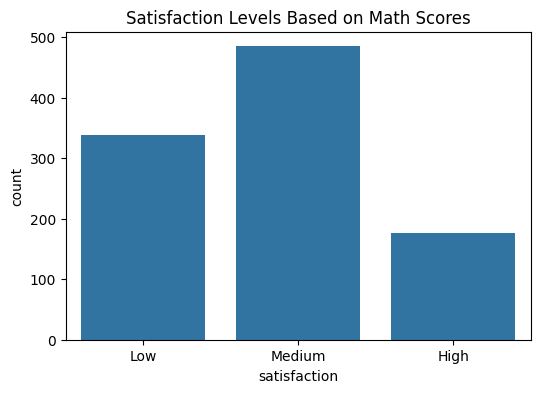

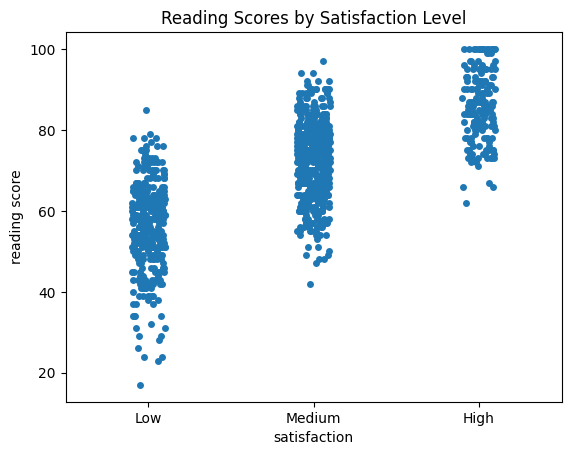

In [ ]:
df_ordinal = pd.read_csv("Datasets/StudentsPerformance.csv")

# Add an ordinal column (simulate satisfaction)
import numpy as np
df_ordinal['satisfaction'] = np.where(df_ordinal['math score'] > 80, 'High',
                             np.where(df_ordinal['math score'] > 60, 'Medium', 'Low'))

df_ordinal['satisfaction'] = pd.Categorical(df_ordinal['satisfaction'], categories=['Low', 'Medium', 'High'], ordered=True)

# Ordered bar chart
plt.figure(figsize=(6,4))
sns.countplot(x='satisfaction', data=df_ordinal, order=['Low', 'Medium', 'High'])
plt.title("Satisfaction Levels Based on Math Scores")
plt.show()

# Strip plot
sns.stripplot(x='satisfaction', y='reading score', data=df_ordinal, order=['Low', 'Medium', 'High'])
plt.title("Reading Scores by Satisfaction Level")
plt.show()

Interval Data

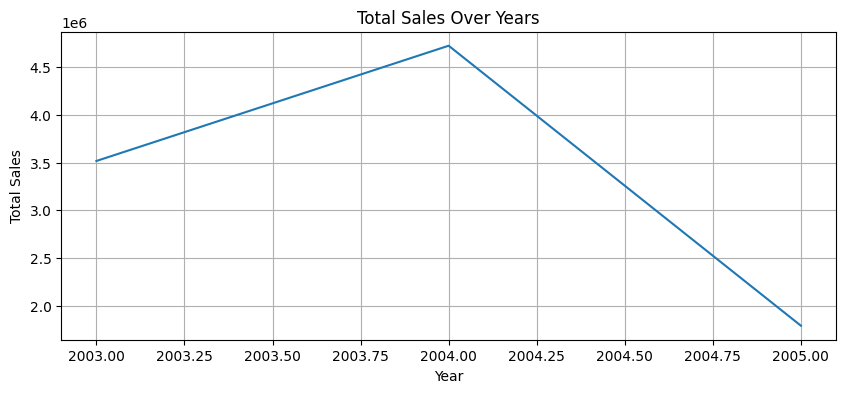

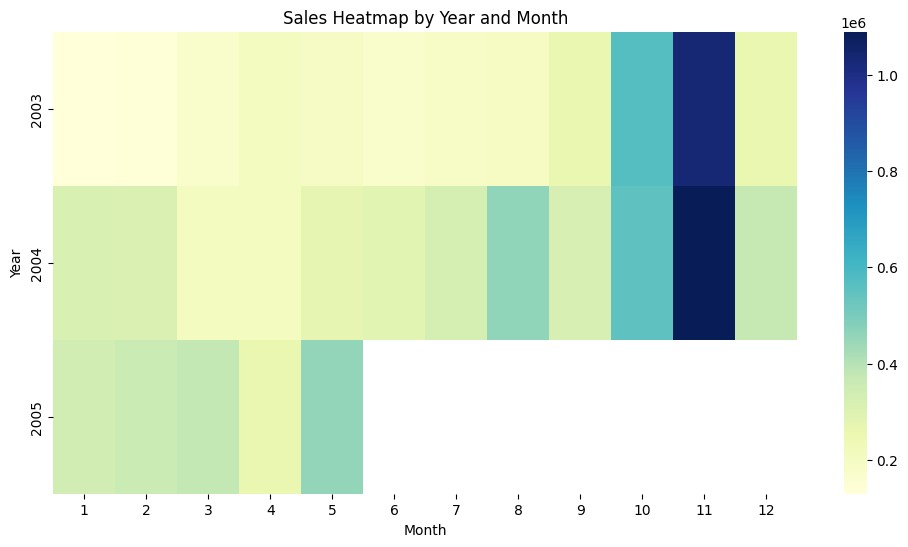

C:\Users\Admin\AppData\Local\Temp\ipykernel_7544\3808485595.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='SALES', data=avg_sales, palette='magma')


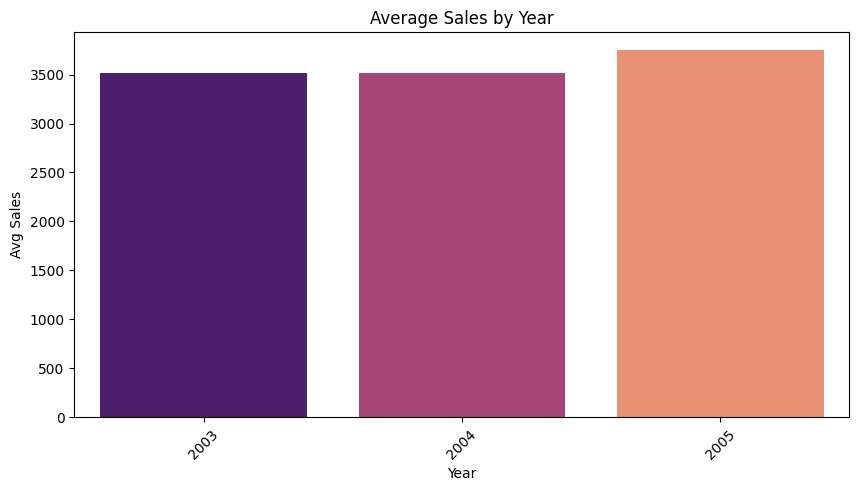

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_sales = pd.read_csv("Datasets/sales_data_sample.csv", encoding='ISO-8859-1')

# Convert ORDERDATE to datetime
df_sales['ORDERDATE'] = pd.to_datetime(df_sales['ORDERDATE'])

# Filter data from year 2000 onwards
df_recent = df_sales[df_sales['YEAR_ID'] >= 2000].copy()

# Extract Year and Month
df_recent['Year'] = df_recent['ORDERDATE'].dt.year
df_recent['Month'] = df_recent['ORDERDATE'].dt.month

# 1. Line Chart (Total Sales Over Time)
plt.figure(figsize=(10, 4))
yearly_sales = df_recent.groupby('Year')['SALES'].sum().reset_index()
sns.lineplot(data=yearly_sales, x='Year', y='SALES')
plt.title('Total Sales Over Years')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

# 2. Heatmap (Monthly Sales by Year)
pivot_sales = df_recent.pivot_table(index='Year', columns='Month', values='SALES', aggfunc='sum')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_sales, cmap='YlGnBu', annot=False)
plt.title('Sales Heatmap by Year and Month')
plt.ylabel('Year')
plt.xlabel('Month')
plt.show()

# 3. Bar Chart (Average Sales per Year)
avg_sales = df_recent.groupby('Year')['SALES'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(x='Year', y='SALES', data=avg_sales, palette='magma')
plt.title('Average Sales by Year')
plt.ylabel('Avg Sales')
plt.xticks(rotation=45)
plt.show()


Ratio Data

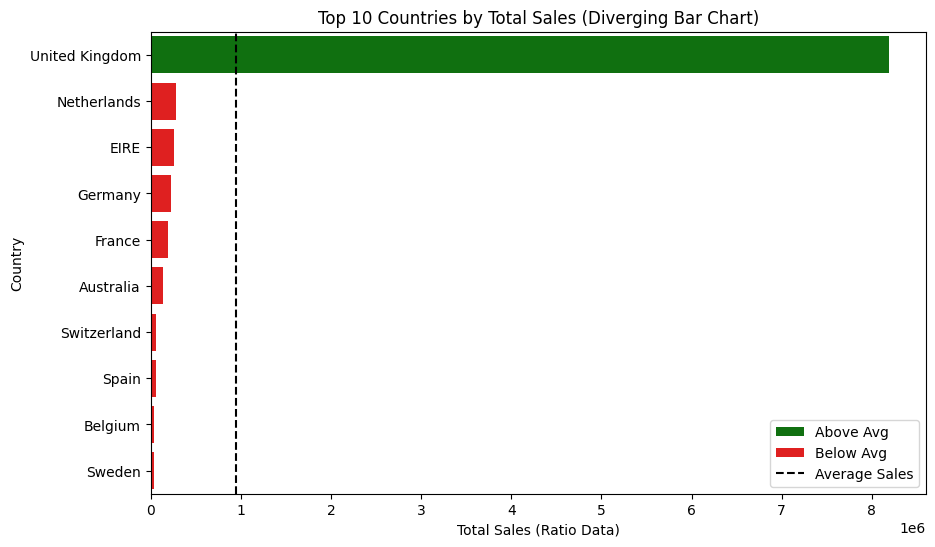

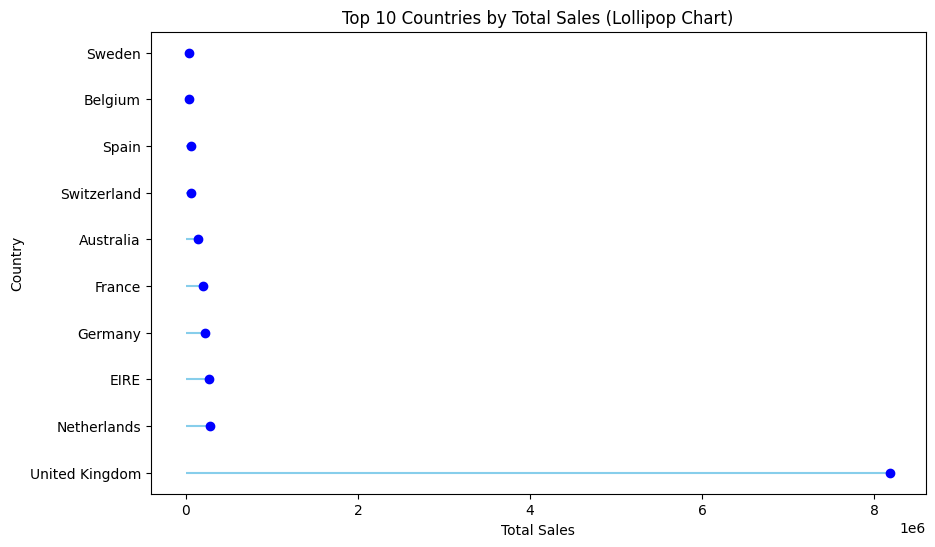

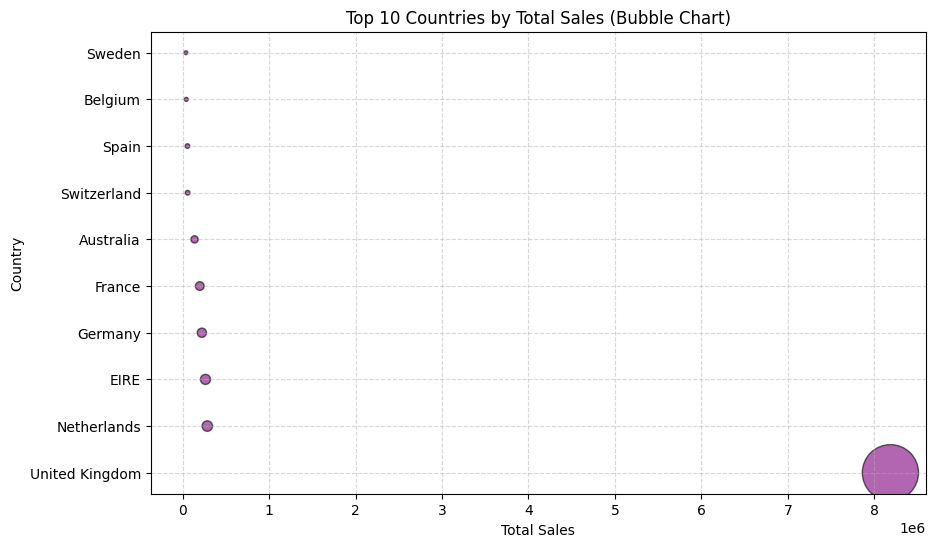

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Datasets/data.csv", encoding='ISO-8859-1')

# Compute total sales
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

# Group by country and get top 10 countries by total sales
country_sales = df.groupby('Country')['TotalSales'].sum().sort_values(ascending=False).head(10)

# Prepare DataFrame for visualization
country_df = country_sales.reset_index()
country_df.columns = ['Country', 'TotalSales']

mean_sales = country_df['TotalSales'].mean()
country_df['SalesType'] = ['Above Avg' if val > mean_sales else 'Below Avg' for val in country_df['TotalSales']]

plt.figure(figsize=(10,6))
sns.barplot(data=country_df, x='TotalSales', y='Country', hue='SalesType', dodge=False,
            palette={'Above Avg':'green', 'Below Avg':'red'})
plt.axvline(mean_sales, color='black', linestyle='--', label='Average Sales')
plt.title('Top 10 Countries by Total Sales (Diverging Bar Chart)')
plt.xlabel('Total Sales (Ratio Data)')
plt.ylabel('Country')
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
plt.hlines(y=country_df['Country'], xmin=0, xmax=country_df['TotalSales'], color='skyblue')
plt.plot(country_df['TotalSales'], country_df['Country'], "o", color='blue')
plt.title('Top 10 Countries by Total Sales (Lollipop Chart)')
plt.xlabel('Total Sales')
plt.ylabel('Country')
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(x=country_df['TotalSales'], y=country_df['Country'], 
            s=country_df['TotalSales'] / 5000, alpha=0.6, color='purple', edgecolors='black')
plt.title('Top 10 Countries by Total Sales (Bubble Chart)')
plt.xlabel('Total Sales')
plt.ylabel('Country')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
